In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('credit_risk_dataset.csv')


# Fase 1: Análise Exploratória de Dados (EDA)

#### Descritiva e Estatística:
Exiba explicitamente o tamanho total da base (linhas e colunas), 
os tipos de dados de cada variável e o sumário estatístico descritivo 
(médias, mínimos, máximos e quartis via .describe()) e etc

In [2]:

display(df) # DataFrame
print(f"Dimensões: Linhas: {df.shape[0]} - Colunas: {df.shape[1]}\n") # Dimensão
print(f"Tipos de Dados:\n{df.dtypes}") # Tipo de dados
df.describe() # Estatísticas



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


Dimensões: Linhas: 32581 - Colunas: 12

Tipos de Dados:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


#### Gráficos

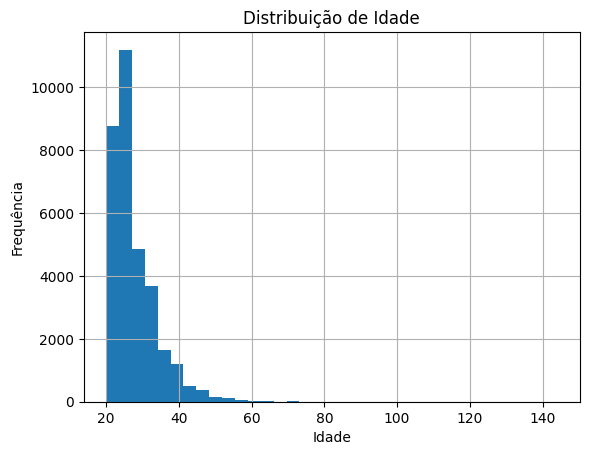

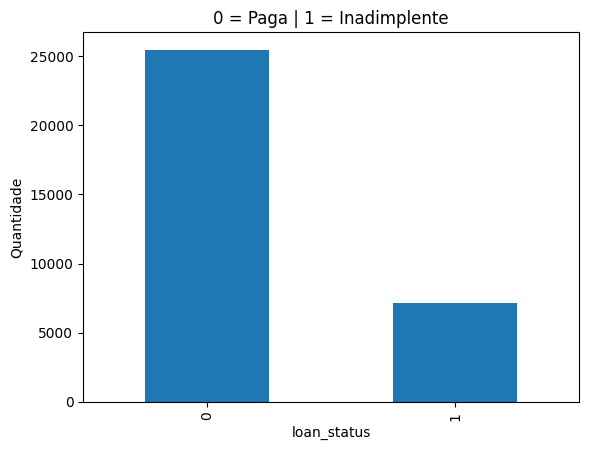

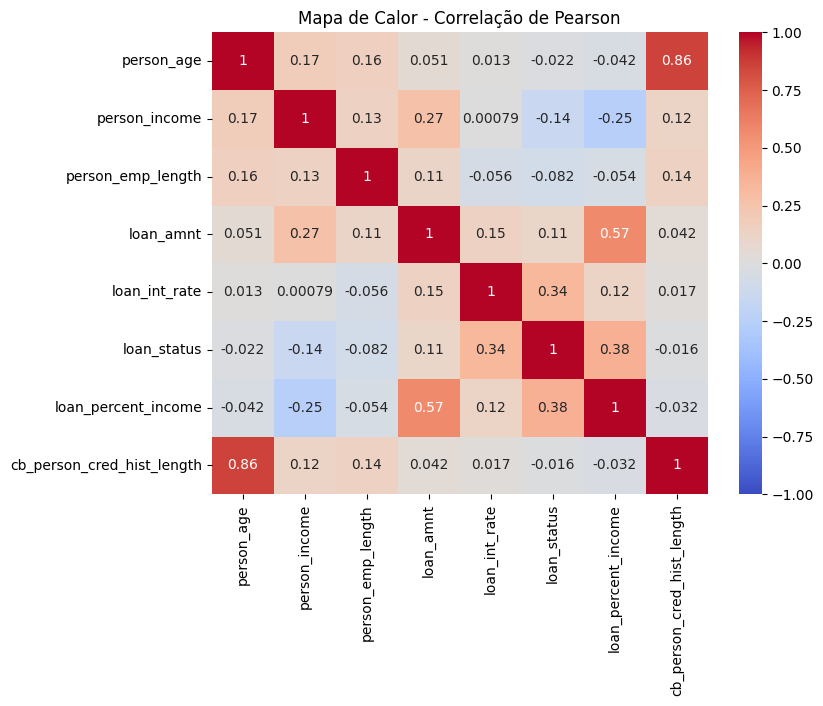

In [3]:
#Histograma
df['person_age'].hist(bins=35)
plt.title('Distribuição de Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

#Gráfico de Barra #
df['loan_status'].value_counts().plot(kind='bar')
plt.title('0 = Paga | 1 = Inadimplente')
plt.xlabel('loan_status')
plt.ylabel('Quantidade')
plt.show()

#Gráfico Pearson
matriz_correlacao = df.corr(method='pearson', numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Calor - Correlação de Pearson')
plt.show()

### Tomada de Decisão: Escreva um parágrafo analítico interpretando o que a estatística e os gráficos revelaram sobre os dados e como isso guiará sua estratégia de preparação.
- Através do comando describe foi possível verificar que existe Outliers na coluna Idade
- Foi possível comprovar o outlier idade
- Através da correlação de Pearson o Heatmap mostrou que a coluna alvo: loan_status tem certa relação com as colunas loan_int_rate e loan_percent_income
- teste

# Fase 2: Tratamento e Limpeza

### Limpeza de Duplicadas:

In [4]:
df_limpo = df.copy()

print(f"Quantidade de Linhas Duplicadas: {df_limpo.duplicated().sum()}") # Soma total das linhas duplicadas
#display(df_limpo[df_limpo.duplicated()])
print(f"Linhas antes da remoção: {df_limpo.shape[0]}")
df_limpo = df_limpo.drop_duplicates()
print(f"Linhas após remoção: {df_limpo.shape[0]}") 

Quantidade de Linhas Duplicadas: 165
Linhas antes da remoção: 32581
Linhas após remoção: 32416


### Verificação e Tratamento de Valores Nulos:

In [5]:
# Identificação de Colunas com dados ausentes
print(f"Coluna:                   Nulos:\n{df_limpo.isna().sum()}")
print('\nPorcentagem de dados Ausentes:')

#Calculando porcentagem de ausentes em relação ao total de registros
porcentagem = (df_limpo.isna().mean() * 100)
print((porcentagem[porcentagem > 0]))

Coluna:                   Nulos:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Porcentagem de dados Ausentes:
person_emp_length    2.736303
loan_int_rate        9.547754
dtype: float64


#### Tratamento da Coluna person_emp_length (Tempo de emprego)

In [6]:
# Imputar Mediana na coluna person_emp_length
mediana_person_emp_length = df_limpo['person_emp_length'].median()
df_limpo['person_emp_length'] = df_limpo['person_emp_length'].fillna(mediana_person_emp_length)
print("Nulos restantes:", df_limpo['person_emp_length'].isna().sum())

Nulos restantes: 0


#### Tratamento Coluna loan_int_rate (Taxa de Juros)
- Teste para verificar a melhor abordagem para tratar os valores ausentes
- Verificando se ha correlação entre a variável loan_grade(Classificação) e a variável alvo: "loan_status", caso tenha uma relação fraca/moderada/forte, será importante tratar os dados ausentes da melhor maneira para evitar distorções
- Verificado que Linhas com loan_int_rate(Taxa de Juros) ausentes possuem Classificações preenchidas
- Possibilidade de linhas com loan_int_rate(Taxa de Juros) preenchidos possuírem Medianas diferentes por loan_grade(classificações), pois classificações recebem taxas de juros diferentes
- Se a hipótese for comprovada seria interessante comparar a "Mediana geral" de todas as Classificações com a "Mediana individual" de cada Classificação e comprovar se a mediana geral pode causar distorções


In [7]:
#Mapeamento de coluna nominal para numeral
ordem_classificacao = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
teste_classificacao_num = df_limpo['loan_grade'].map(ordem_classificacao)
#Verificar Correlação com a Coluna alvo: 
correlacao_classificacao = teste_classificacao_num.corr(df_limpo['loan_status'])
print("\nCORRELAÇÃO: loan_grade x loan_status:", correlacao_classificacao)
#Ver porcentagem de cada classificação
porcentagem = (df_limpo['loan_grade'].value_counts(normalize=True) * 100).round(2)
print(f"Porcentagem das Classificações em Relação ao Todo:\n{porcentagem.astype(str) + '%'}")

#Verificar As medianas para tomada de decisão 
print("\n-----Medianas------")
#Verificar Mediana Geral e Comparar com a Mediana por Classificação
print("MEDIANA GERAL:", df_limpo['loan_int_rate'].median())
print("MEDIANA POR CLASSIFICAÇÃO:\n", df_limpo.groupby('loan_grade')['loan_int_rate'].median())

#Imputação
medianas_classificacao = df_limpo.groupby('loan_grade')['loan_int_rate'].median() #Agrupa a Mediana por Classificação (A,B,C,D,E,F,G)

medianas_classificacao_num = df_limpo['loan_grade'].map(medianas_classificacao) #Alinhar indices mediana por letra para com índice de cada linha da base possibilitando usar o fillna

df_limpo['loan_int_rate'] = (df_limpo['loan_int_rate'].fillna(medianas_classificacao_num))

# Após Tratamento
print("Nulos restantes:", df_limpo['loan_int_rate'].isna().sum())


CORRELAÇÃO: loan_grade x loan_status: 0.3734358099174051
Porcentagem das Classificações em Relação ao Todo:
loan_grade
A    33.02%
B    32.04%
C    19.86%
D    11.17%
E     2.97%
F     0.74%
G      0.2%
Name: proportion, dtype: object

-----Medianas------
MEDIANA GERAL: 10.99
MEDIANA POR CLASSIFICAÇÃO:
 loan_grade
A     7.490
B    10.990
C    13.480
D    15.310
E    16.820
F    18.535
G    20.160
Name: loan_int_rate, dtype: float64
Nulos restantes: 0


#### Justificativa de tratamento de valores ausentes:
- Para a coluna person_emp_length (Tempo de Emprego) foi escolhida a estratégia de imputar pela mediana porque existe um erro de digitação que distorce a média.
- A coluna loan_int_rate (Taxa de Juros) possui 9.5% de dados ausentes e tem correlação moderada (0,34) com a variável alvo "loan_status". Foi observado que a Taxas de Juros é influenciada pela Classificação, pois a Mediana da Taxa de Juros de cada classificação é diferente. Por exemplo a variação de 7,49(Classificação A) a 20,16(Classificação G), a imputação da Mediana Geral (10.99) ocasionaria distorções, pois atribuiria valores de taxas de juros irreais a clientes de risco muito diferente entre si, distorcendo os perfis para previsão.


### Tratamento de Outliers

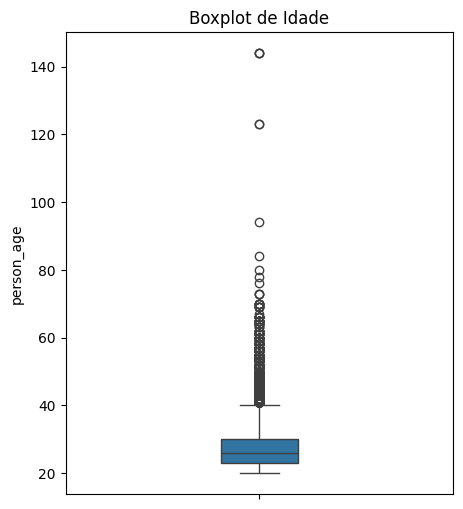

Idade máxima antes: 144
Mediana da Idade: 26.0
Quantidade acima de 100: 5
Porcentagem Outliers acima de 100: 0.0154%
Idade máxima depois de Tratado: 94


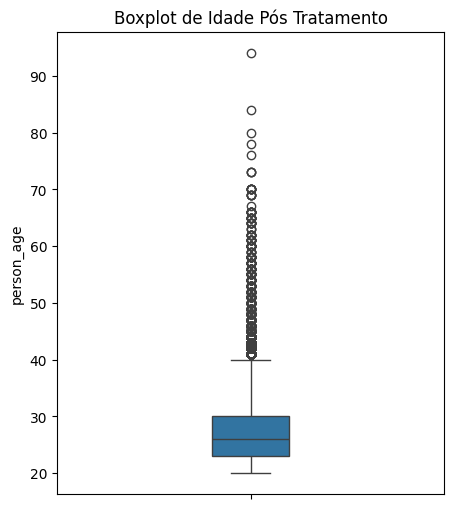

 ------------------------------------------------- 


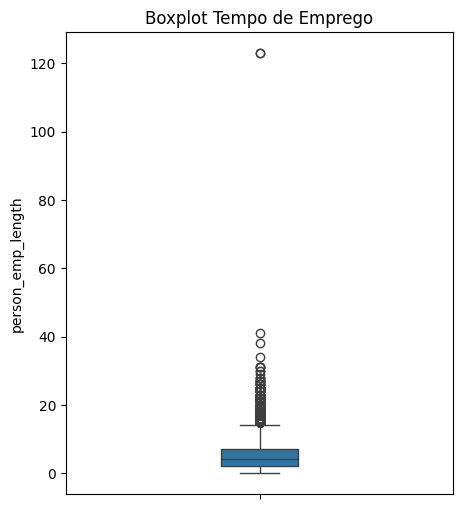

Linhas antes: 32411
Tempo Máximo de Emprego Antes 123.0
Quantidade Acima de 50: 2
Linhas depois: 32409
Tempo Máximo de Emprego depois de Tratado: 41.0


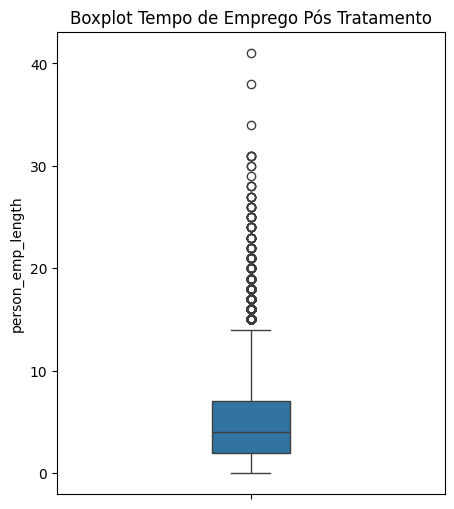

In [8]:
#BoxPlot Idade
plt.figure(figsize=(5, 6))
sns.boxplot(data=df_limpo['person_age'], width=0.2)
plt.title("Boxplot de Idade")
plt.show()

#Tratamento Idade
print("Idade máxima antes:", df_limpo['person_age'].max()) #Para fins de estatística
print("Mediana da Idade:", df_limpo['person_age'].median()) #Para fins de estatística
print("Quantidade acima de 100:", (df_limpo['person_age'] > 100).sum()) #Para fins de estatística
porcentagem = ((df_limpo["person_age"] > 100).mean() * 100) # Verificar a porcentagem de Outliers acima de 100
print(f"Porcentagem Outliers acima de 100: {porcentagem:.4f}%")

df_limpo = df_limpo[df_limpo['person_age'] < 100] #Tratamento dos dados via Remoção
print("Idade máxima depois de Tratado:", df_limpo['person_age'].max())

#BoxPlot Idade Após Tratamento
plt.figure(figsize=(5, 6))
sns.boxplot(data=df_limpo['person_age'], width=0.2)
plt.title("Boxplot de Idade Pós Tratamento")
plt.show()

print(" ------------------------------------------------- ")

#BoxPlot Tempo de Emprego 
plt.figure(figsize=(5, 6))
sns.boxplot(data=df_limpo['person_emp_length'], width=0.2)
plt.title("Boxplot Tempo de Emprego")
plt.show()

#Tratamento Tempo de Emprego - Remoção
print("Linhas antes:", df_limpo.shape[0])
print("Tempo Máximo de Emprego Antes", df_limpo['person_emp_length'].max())
print("Quantidade Acima de 50:", (df_limpo['person_emp_length'] > 50).sum())
df_limpo = df_limpo[df_limpo['person_emp_length'] < 50]
print("Linhas depois:", df_limpo.shape[0])
print("Tempo Máximo de Emprego depois de Tratado:", df_limpo['person_emp_length'].max())

#BoxPlot Tempo de Emprego Após Tratamento
plt.figure(figsize=(5, 6))
sns.boxplot(data=df_limpo['person_emp_length'], width=0.2)
plt.title("Boxplot Tempo de Emprego Pós Tratamento")
plt.show()



### 

#### Decisão Tratamento:
- Na coluna "person_age" (idade) foi identificado através do BoxPlot e Fase 1 EDA alguns Outliers considerados como "Artificiais" (Erros de digitação), cinco valores superiores a 100, um percentual de 0.0154% do total de registros, foi aplicado o "Tratamento de Remoção" excluindo os registros acima de 100, preservando outliers naturais(40 a 94) e mitigando inconsistências para uso nos modelos preditivos. 
- Coluna "person_emp_length" (Tempo de Emprego), após análise visual foi identificado 2 outliers extremos com valor máximo de 123 anos, em relação aos outliers naturais de no máximo 41. Foi aplicado o "Tratamento de Remoção" excluindo os registros acima de 50 anos visando preservar a integridade da base. 

#### Impacto nos Modelos: 
- KNN: Muito vulnerável a outliers, porque ele decide quem é parecido com quem calculando a distância entre os dados, reduzir outliers extremos é fundamental para que o modelo não cometa erros. Calcula a proximidade entre dados usando fórmulas de distância geométrica no espaço multidimensional
- Árvore de decisão: É mais robusta a outliers, porém pode sofrer overfitting criando galhos isolados, por isso é bom tratar outliers extremos.